# 03. Modeling and Evaluation

초기 100사이클 피처로 `log10(cycle_life)`를 예측하고, 사이클 단위로 되돌려 **MAPE**로 평가합니다.

- **Batch 1**은 Train과 Valid로 나누고, **Batch 2는 Test, Batch 3는 추가 Test**로 씁니다. Batch 2, 3은 모델 선택에 쓰지 않았습니다.
- Train과 Valid는 **충전 프로토콜 단위로 분리**합니다. 같은 충전 프로토콜의 셀이 양쪽에 걸치면 모델이 새 셀이 아니라 이미 본 충전 프로토콜을 맞히게 되기 때문입니다.
- 정제 수정 이력: Test를 본 뒤 데이터 품질 문제 두 가지(EOL 미도달 라벨 5셀, ΔQ 사이클 인덱스)를 고쳐 다시 돌렸습니다. 수정 이전 결과는 `results/v1_before_fix/`에 남겨 두었고 자세한 내용은 README에 있습니다.

구성: 1. 데이터 분할 → 2. 검증 설계 → 3. 모델 선택 → 4. 성능 → 5. 오류 분석

> `python -m src.train --eval-batches 2 3`과 같은 결과를 단계별로 보여 줍니다.

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))      # 저장소 루트를 경로에 추가 (src/ 임포트용)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

# 그래프 공통 스타일 (그림 안 글자는 폰트 의존을 피하려고 영문으로 작성)
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().parent                         # 저장소 루트
FIG = ROOT / "results" / "figures"               # 그림 저장 위치

## 1. 데이터 분할

Batch 1(36셀)을 충전 프로토콜 단위로 Train과 Valid로 나눕니다. 충전 프로토콜이 겹치지 않는지 `assert`로 확인합니다.

In [2]:
from src.train import load_data, compare_models, FEATURE_SETS, STAGES
from src.validation import group_holdout

df = load_data(ROOT / "data")
b1 = df[df.batch == 1].reset_index(drop=True)

tr_i, va_i, chosen = group_holdout(b1, 42)               # 충전 프로토콜 단위 Hold-out, seed 고정
TR, VA = b1.loc[tr_i].reset_index(drop=True), b1.loc[va_i].reset_index(drop=True)
assert set(TR.policy).isdisjoint(VA.policy)              # Train 과 Valid 에 같은 충전 프로토콜이 없어야 함

print(f"Batch 1 {len(b1)}셀, 충전 프로토콜 {b1.policy.nunique()}개 → Train {len(TR)}셀 / Valid {len(VA)}셀")
print("Valid 충전 프로토콜:", chosen)
print("Valid 수명:", sorted(VA.cycle_life.astype(int)))
print("Train 수명 범위:", int(TR.cycle_life.min()), "~", int(TR.cycle_life.max()))

Batch 1 36셀, 충전 프로토콜 20개 → Train 29셀 / Valid 7셀
Valid 충전 프로토콜: ['6C(40%)-3C', '4.8C(80%)-4.8C', '5.4C(40%)-3.6C', '7C(40%)-3.6C']
Valid 수명: [617, 625, 636, 854, 870, 1017, 1054]
Train 수명 범위: 534 ~ 1074


Valid는 7셀(4개 충전 프로토콜)로 작아서 한 번의 분할 결과가 우연에 흔들릴 수 있습니다. 그래서 Valid 점수 하나에 의존하지 않고, 아래에서 여러 번 반복한 CV 점수를 모델 선택 기준으로 씁니다.

## 2. 검증 설계 변경 근거

**CV는 Cross-Validation(교차검증)의 약자**로, 데이터를 여러 조각으로 나눠 조각을 바꿔 가며 검증하고 그 평균을 점수로 쓰는 방법입니다.

Day 1에는 셀 단위 **랜덤 CV**를 계획했는데, Batch 1은 충전 프로토콜 20개에 충전 프로토콜당 셀이 1∼2개입니다. 랜덤으로 나누면 같은 충전 프로토콜의 형제 셀이 학습에 들어가 점수가 좋게 나옵니다. 그래서 같은 충전 프로토콜을 한 덩어리로 묶는 **충전 프로토콜 단위 CV**로 바꿨고, 두 방식이 실제로 얼마나 다른지 같은 모델과 피처로 비교합니다.

,featset,model,n_feat,CV_group,CV_group_sd,CV_random,CV_random_sd,CV_extrap,score_stage2,Valid
0,D6 dQ4+QD2+QDmax,ElasticNet,6,5.500,1.400,5.200,1.400,6.800,6.100,7.500
1,D6 dQ4+QD2+QDmax,Ridge,6,5.600,1.400,5.300,1.400,6.300,6.000,7.500
2,D6 dQ4+QD2+QDmax,Linear,6,5.700,1.800,5.400,1.400,6.900,6.300,7.700
3,D6 dQ4+QD2+QDmax,GPR,6,6.500,3.500,5.500,1.400,12.300,9.400,8.000
4,D6 dQ4+QD2+QDmax,PLS(2),6,7.200,2.700,6.200,2.300,13.000,10.100,8.500
5,D4 dQ4,Linear,4,8.300,2.100,8.000,2.500,14.000,11.100,9.200
6,V2 var+min,PLS(2),2,8.300,1.900,7.800,2.300,15.000,11.700,8.700
7,V2 var+min,Linear,2,8.300,1.900,7.800,2.300,15.000,11.700,8.700
8,D4 dQ4,ElasticNet,4,8.700,2.000,8.300,2.400,15.600,12.100,9.200
9,V2 var+min,ElasticNet,2,8.700,2.000,8.200,2.600,15.000,11.800,8.800


충전 프로토콜 단위 CV 가 랜덤 CV 보다 나쁜 조합: 27/27, 평균 차이 0.9%p


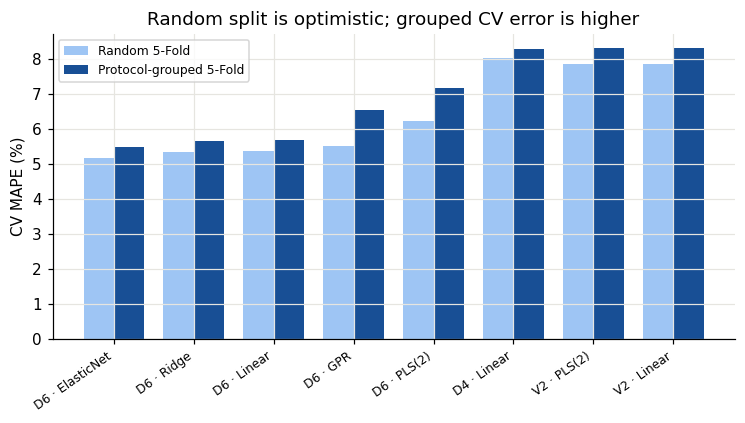

In [3]:
cv = compare_models(TR, VA).sort_values("CV_group").reset_index(drop=True)    # 27개 조합의 CV, 외삽 CV, Valid 점수
display(cv.round(1))

gap = cv.CV_group - cv.CV_random
print(f"충전 프로토콜 단위 CV 가 랜덤 CV 보다 나쁜 조합: {(gap > 0).sum()}/{len(cv)}, 평균 차이 {gap.mean():.1f}%p")

top = cv.head(8); labels = top.featset.str.split().str[0] + " · " + top.model
fig, ax = plt.subplots(figsize=(8, 3.6)); x, w = np.arange(len(top)), .38
ax.bar(x - w / 2, top.CV_random, w, color="#9ec5f4", label="Random 5-Fold")
ax.bar(x + w / 2, top.CV_group, w, color="#184f95", label="Protocol-grouped 5-Fold")
ax.set_xticks(x, labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("CV MAPE (%)"); ax.legend(fontsize=8)
ax.set_title("Random split is optimistic; grouped CV error is higher")
fig.savefig(FIG / "cv_random_vs_group.png", dpi=180, bbox_inches="tight"); plt.show()

27개 조합 **모두** 충전 프로토콜 단위 CV가 랜덤 CV보다 나쁩니다(평균 +0.9%p). 차이의 크기는 데이터 정제에 따라 달라졌지만 방향은 한 번도 뒤집히지 않았습니다. 랜덤 분할이 낙관적이라고 판단하고 충전 프로토콜 단위로 바꾼 이유입니다. 방향이 Day 1과 반대로 바뀐 것이 아니라, 랜덤 CV에서 충전 프로토콜 단위 CV로 옮긴 것입니다.

## 3. 모델 선택

선택은 Train 안의 점수로만 합니다. 규칙은 두 단계로 나눠 두었습니다.

- **1차, 사전 확정**: 충전 프로토콜 단위 CV MAPE가 가장 낮은 조합을 고릅니다.
- **개선 단계**: Test에서 큰 격차를 본 뒤, 수명이 가장 짧은 충전 프로토콜을 통째로 검증으로 빼는 **외삽 CV**를 만들었습니다. 외삽은 학습 범위 밖을 예측하는 일이고, Batch 2에 학습 최솟값(534)보다 짧은 셀이 많았기 때문에 이 상황을 Batch 1 안에서 흉내 낸 것입니다. 선택 기준은 외삽 CV 값을 보기 전에 `(충전 프로토콜 단위 CV + 외삽 CV) / 2`로 정해 두었습니다.

In [4]:
for stage, (label, key) in STAGES.items():
    best = cv.sort_values(key).iloc[0]
    print(f"{label:24s} 기준 {key:13s} → {best.featset} / {best.model}   CV {best.CV_group:.1f}, 외삽 CV {best.CV_extrap:.1f}")

cols = ["featset", "model", "CV_group", "CV_extrap", "score_stage2", "Valid"]
display(cv.sort_values("score_stage2")[cols].head(10).round(1))

1차 (사전 확정)               기준 CV_group      → D6 dQ4+QD2+QDmax / ElasticNet   CV 5.5, 외삽 CV 6.8
개선 후 (외삽 검증 반영)          기준 score_stage2  → D6 dQ4+QD2+QDmax / Ridge   CV 5.6, 외삽 CV 6.3


,featset,model,CV_group,CV_extrap,score_stage2,Valid
1,D6 dQ4+QD2+QDmax,Ridge,5.600,6.300,6.000,7.500
0,D6 dQ4+QD2+QDmax,ElasticNet,5.500,6.800,6.100,7.500
2,D6 dQ4+QD2+QDmax,Linear,5.700,6.900,6.300,7.700
3,D6 dQ4+QD2+QDmax,GPR,6.500,12.300,9.400,8.000
4,D6 dQ4+QD2+QDmax,PLS(2),7.200,13.000,10.100,8.500
10,V1 var,Linear,8.700,12.600,10.700,9.700
5,D4 dQ4,Linear,8.300,14.000,11.100,9.200
7,V2 var+min,Linear,8.300,15.000,11.700,8.700
6,V2 var+min,PLS(2),8.300,15.000,11.700,8.700
9,V2 var+min,ElasticNet,8.700,15.000,11.800,8.800


피처셋 이름의 뜻은 다음과 같습니다. **D6**은 ΔQ 통계 4개(`dq_log_var`, `dq_log_abs_min`, `dq_skew`, `dq_kurt`)에 `QD_2`와 `QD_max_minus_2`를 더한 6개 피처이고, V1은 `dq_log_var` 하나(논문 베이스라인), D4는 ΔQ 통계 4개입니다.

1차에서는 D6 + ElasticNet이, 개선 단계에서는 D6 + Ridge가 뽑혔습니다. 상위 모델들의 CV 점수는 5.5, 5.6, 5.7로 표준편차(약 1.4)보다 훨씬 가까워 사실상 같은 수준입니다. 그래서 선택 기준을 바꿔도 거의 같은 모델이 나왔습니다. 외삽 CV에서는 선형 계열이 GPR보다 유리했습니다.

## 4. 성능

교수님 형식의 표입니다. Gap은 양수일수록 성능이 나빠지는 방향입니다.

- Train-Valid = Valid − Train: 크면 과적합을 의심
- Valid-Test = Test − Valid: 크면 배치 간 일반화가 떨어졌다는 뜻
- Target-Test = Test − 9.1: 논문의 9.1%와의 차이

In [5]:
display(pd.read_csv(ROOT / "results" / "model_performance.csv"))     # 1차 와 개선 후
display(pd.read_csv(ROOT / "results" / "baseline_vs_final.csv"))     # 논문 베이스라인과 비교 (모델 선택에는 미사용)

,구분,1차 MAPE (%),개선 후 MAPE (%),비고 (개선 후)
0,Train (Batch 1 CV),5.500,5.600,"충전 프로토콜 단위 Repeated 5-Fold x10, SD=1.4"
1,Valid (Batch 1 Hold-out),7.500,7.500,충전 프로토콜 단위 Hold-out 7셀; 30개 시드 평균 6.0+-1.4 (범위...
2,Test (Batch 2),26.900,27.500,"Batch1 전체(36셀) 재학습, n=39; Train 부분만 학습 시 27.6"
3,Gap (Train-Valid),2.000,1.900,(+) : 과적합 의심 [Valid - Train]
4,Gap (Valid-Test),19.400,19.900,(+) : 배치간 일반화 저하 의심 [Test - Valid]
5,Gap (Target-Test),17.800,18.400,Target : 원논문 9.1% [Test - Target]
6,Test (Batch 3),9.800,9.800,n=40
7,Gap (Batch2-Batch3),-17.100,-17.700,Test 성능 간 비교 [Batch3 - Batch2]
8,Gap (Target-Test) [Batch 3],0.700,0.700,"Batch 3 기준, 원논문 성능 비교"


,model,train_cv,valid,test_b2,test_b3
0,V1 var / Linear (논문 Variance baseline),8.700,9.700,28.600,11.700
1,D6 dQ4+QD2+QDmax / ElasticNet (1차 (사전 확정)),5.500,7.500,26.900,9.800
2,D6 dQ4+QD2+QDmax / Ridge (개선 후 (외삽 검증 반영)),5.600,7.500,27.500,9.800


**1차 모델 기준으로 읽으면** Train CV 5.5, Valid 7.5로 Gap(Train-Valid)이 +2.0이라 과적합 징후는 작습니다. 반면 Test Batch 2는 26.9로 Valid보다 19.4%p 높아, Batch 1 안에서의 성능이 새 배치로 그대로 이어지지 않았습니다. Test Batch 3는 9.8로 논문 목표(9.1)와 0.7%p 차이입니다.

**개선 단계는 개선되지 않았습니다.** Ridge로 바뀐 뒤 Test Batch 2가 26.9에서 27.5로 소폭 올랐는데, 이 차이는 CV 표준편차(1.4)보다 작아 노이즈 수준입니다. 외삽 CV는 Batch 1 안의 상황이라, Batch 2의 오차 원인(배치 간 차이)을 해결하지 못했습니다. 그래서 사전에 정한 1차 모델을 최종으로 유지합니다.

참고로 논문 베이스라인(`dq_log_var` 선형)도 Test Batch 2가 28.6, Batch 3가 11.7로 최종 모델과 2%p 안팎입니다. 이 차이로 최종 모델이 의미 있게 낫다고 말하기는 어렵습니다.

## 5. 오류 분석

Batch 2와 Batch 3에서 오차가 어떻게 나뉘는지 봅니다. 평균 편향은 `(예측 − 실제) / 실제`의 평균이며 양수면 실제보다 길게 예측했다는 뜻입니다.

In [6]:
P = pd.read_csv(ROOT / "results" / "stage1" / "predictions.csv")
lo, hi = b1.cycle_life.min(), b1.cycle_life.max()                    # Train 수명 범위

def prep(split):
    t = P[P.split == split].copy()
    t["signed_%"] = (t.pred - t.cycle_life) / t.cycle_life * 100
    t["Train 수명 범위"] = np.where(t.cycle_life < lo, "범위 아래", np.where(t.cycle_life > hi, "범위 위", "범위 안"))
    return t

T, T3 = prep("Test(B2)"), prep("Test(B3)")
print(f"Batch 2: 실제보다 길게 예측한 셀 {(T['signed_%'] > 0).mean():.0%}, 예측 최솟값 {T.pred.min():.0f} (Train 최솟값 {lo:.0f})")

for name, t in (("Batch 2", T), ("Batch 3", T3)):
    print(f"\n[{name}] MAPE {t.ape.mean():.1f}%, 평균 편향 {t['signed_%'].mean():+.1f}%")
    display(t.groupby("Train 수명 범위").agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 평균편향=("signed_%", "mean")).round(1))

print("\n[Batch 2] newstructure 여부별")
display(T.groupby("new_structure").agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 평균편향=("signed_%", "mean")).round(1))
display(T.sort_values("ape", ascending=False).head(6)[["cell_id", "policy", "cycle_life", "pred", "ape"]].round(1))

Batch 2: 실제보다 길게 예측한 셀 97%, 예측 최솟값 431 (Train 최솟값 534)

[Batch 2] MAPE 26.9%, 평균 편향 +26.2%


,셀수,MAPE,평균편향
Train 수명 범위,,,
범위 아래,30,23.400,22.500
범위 안,7,47.900,47.900
범위 위,2,6.600,6.600



[Batch 3] MAPE 9.8%, 평균 편향 +1.5%


,셀수,MAPE,평균편향
Train 수명 범위,,,
범위 안,27,9.500,5.600
범위 위,13,10.500,-7.200



[Batch 2] newstructure 여부별


,셀수,MAPE,평균편향
new_structure,,,
False,30,23.400,22.500
True,9,38.700,38.700


,cell_id,policy,cycle_life,pred,ape
40,b2c44,5.2C(58%)-4C-newstructure,841.000,"1,599.700",90.200
38,b2c9,5.6C(26%)-4.5C-newstructure,791.000,"1,357.500",71.600
37,b2c7,4.8C(80%)-4.8C-newstructure,777.000,"1,244.800",60.200
23,b2c13,4.65C(69%)-6C,460.000,657.300,42.900
14,b2c31,5.6C(26%)-4.5C,425.000,599.500,41.100
43,b2c43,4.8C(80%)-4.8C-newstructure,"1,029.000","1,441.800",40.100


- **Batch 2는 거의 모든 셀을 실제보다 길게 예측했습니다.** 학습 수명 범위 아래의 짧은 셀 30개만이 문제가 아니라, 범위 안의 7셀은 오히려 오차가 더 컸습니다. 범위 밖이라는 이유만으로는 오차가 설명되지 않습니다.
- **가장 크게 틀린 셀은 모두 `-newstructure` 셀입니다.** 그런데 Batch 3는 40셀이 전부 `-newstructure`인데도 MAPE가 9.8%이고 편향도 거의 없습니다. 그래서 "newstructure라서 틀린다"고 단정할 수 없고, Batch 2의 오차는 배치 특성과 겹친 것으로 보이나 원인은 확정하지 못했습니다.
- **가설: 초기 용량 피처.** 02번 노트북에서 `QD_2`, `QD_max_minus_2`가 Batch 2에서 값 범위를 크게 벗어나고 부호도 뒤집히는 것을 봤고, 최종 모델이 이 피처를 쓰므로 Batch 2의 편향과 관련이 있을 수 있다고 보았습니다. 모델을 바꾸면 Test를 또 보게 되어, SHAP으로 기여도만 분해해 확인했습니다(04번 노트북). 결과적으로 이 피처들은 Batch 2 평균 편향의 약 5분의 1만 설명했고, 나머지는 ΔQ와 수명 관계가 Batch 2에서 어긋난 데서 왔습니다.

아래 그림은 1차 모델의 예측입니다. 점선 대각선에 가까울수록 정확하고, 왼쪽 세로 점선이 Train 최솟값입니다.

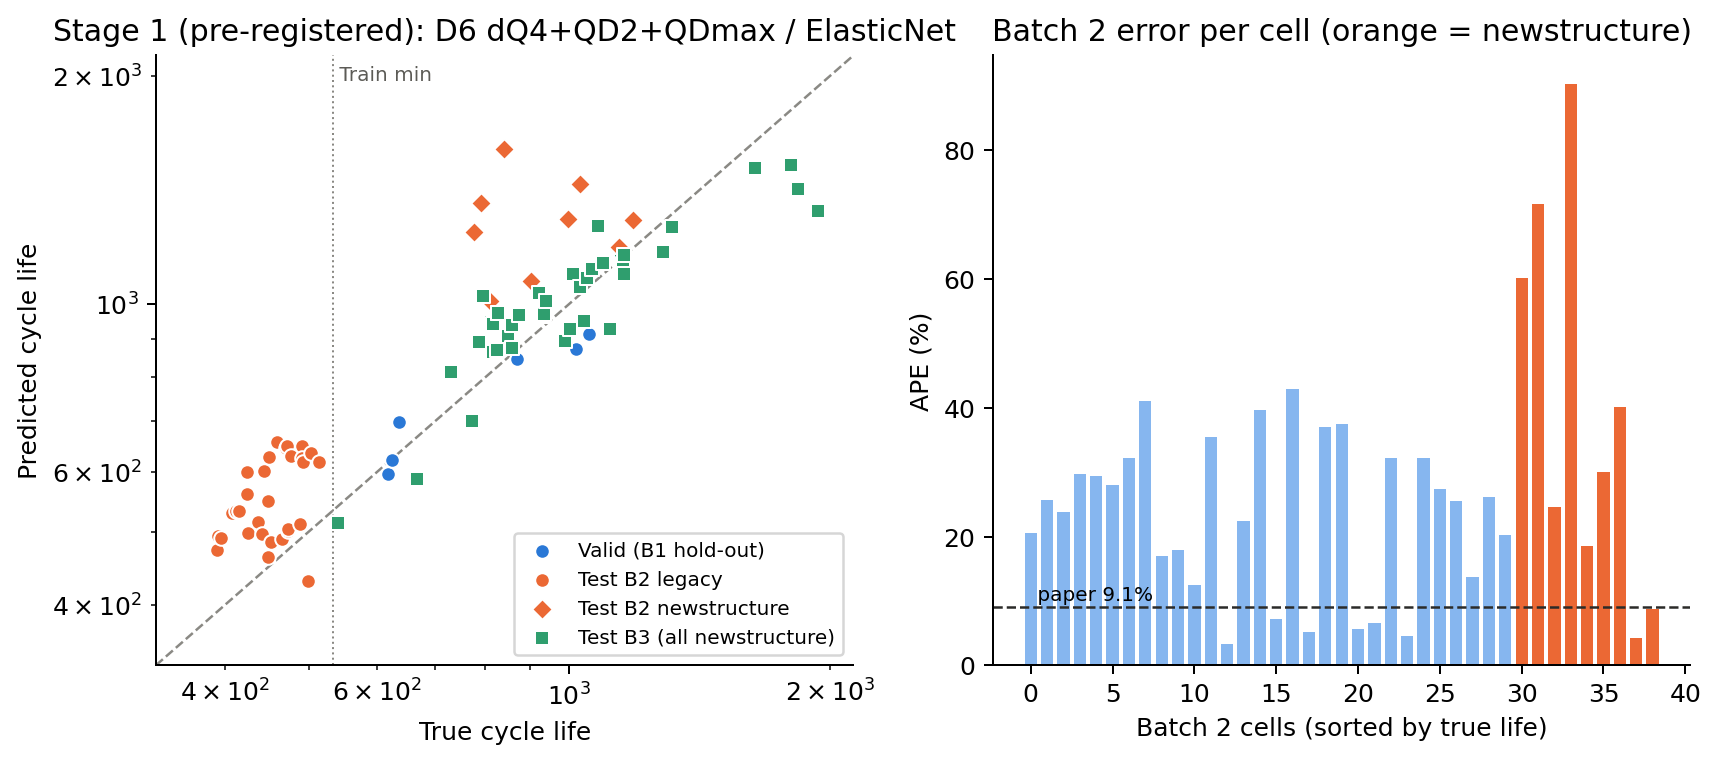

In [7]:
display(__import__("IPython.display", fromlist=["Image"]).Image(str(FIG / "pred_vs_true_stage1.png")))